In [1]:
# grid_agnostic_u_timeseries.ipynb (can also be saved as .py)
# Task: Time-series prediction of wind u(x, t+Δt) from u(x, t), resolution-agnostic.

# What this notebook does
# 1) Loads KS u-trajectories or X/y pairs produced by the professor's notebook.
# 2) Builds multi-resolution variants (regular downsampling + optional irregular masks).
# 3) Adds per-example Fourier positional encodings from the actual x-grid.
# 4) Trains a fully-convolutional 1D model with scalar conditioning and masked, area-weighted loss.
# 5) Evaluates one-step metrics and K-step rollouts (including on unseen resolutions).


# -------------------------------
# Imports and minimal config
# -------------------------------
import os, math, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DATA_DIR = Path(".")                       # folder with KS .npy files
SAVE_DIR = Path("./runs_grid_agnostic")    # where best.pt will be written
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if DEVICE == "cuda":
    print(f"[info] Using CUDA (devices={torch.cuda.device_count()})")
    torch.backends.cudnn.benchmark = True  # Optimize convolutions
    torch.backends.cudnn.deterministic = False  # Allow non-deterministic for speed
    try:
        torch.set_float32_matmul_precision("high")  # Faster matmuls on modern GPUs
    except Exception:
        pass
    # Enable memory efficient attention if available
    try:
        torch.backends.cuda.enable_flash_sdp(True)
    except:
        pass
else:
    print("[info] Using CPU")
    
# Set default tensor type for faster operations (optional)
# torch.set_default_dtype(torch.float32)

# ============================================
# hyperparameters
# ============================================
FREQS = (1, 2, 4, 8)          # Fourier PE frequencies
USE_RESIDUAL_TARGET = True    # predict Δu, then add u
BATCH_SIZE = 64 if DEVICE == "cuda" else 32
LR = 2e-3
EPOCHS = 50
VAL_EVERY = 1

# early stopping
ES_PATIENCE = 6
ES_MIN_DELTA = 1e-5
ES_WARMUP = 5

# small rollout loss during training (stability)
ROLLOUT_K = 0 #3
ROLLOUT_W = 0 #0.10

[info] Using CUDA (devices=1)


/ext3/miniforge3/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [3]:
def try_load_arrays(data_dir: Path):
    """
    Two modes:
      1) supervised_pairs: X_train.npy, y_train.npy, X_val.npy, y_val.npy, X_test.npy, y_test.npy
      2) ks_full: ks_data.npy (+ ks_spatial_grid.npy, ks_time.npy)

    For mode 1 we STILL try to load ks_spatial_grid/ks_time to define Lx, dt.
    """
    sup_files = ["X_train.npy", "y_train.npy", "X_val.npy", "y_val.npy", "X_test.npy", "y_test.npy"]
    if all((data_dir / f).exists() for f in sup_files):
        d = {"mode": "supervised_pairs"}
        for f in sup_files:
            d[f[:-4]] = np.load(data_dir / f)

        # coordinates / time: prefer ks_* if present, else x.npy/t.npy if they exist
        if (data_dir / "ks_spatial_grid.npy").exists():
            d["x"] = np.load(data_dir / "ks_spatial_grid.npy")
        elif (data_dir / "x.npy").exists():
            d["x"] = np.load(data_dir / "x.npy")

        if (data_dir / "ks_time.npy").exists():
            d["t"] = np.load(data_dir / "ks_time.npy")
        elif (data_dir / "t.npy").exists():
            d["t"] = np.load(data_dir / "t.npy")

        print("[info] Found supervised pair files (X_*, y_*)")
        return d

    if (data_dir / "ks_data.npy").exists():
        d = {"mode": "ks_full", "ks_data": np.load(data_dir / "ks_data.npy")}
        if (data_dir / "ks_spatial_grid.npy").exists():
            d["x"] = np.load(data_dir / "ks_spatial_grid.npy")
        if (data_dir / "ks_time.npy").exists():
            d["t"] = np.load(data_dir / "ks_time.npy")
        print("[info] Found ks_data.npy (full KS field)")
        return d

    raise FileNotFoundError("No recognized KS data files found in DATA_DIR.")

def infer_Lx_dt(d):
    if "x" in d:
        x = d["x"]
        Lx = float((x[1] - x[0]) * len(x))
    else:
        Lx = 2 * math.pi
    if "t" in d and len(d["t"]) >= 2:
        dt = float(d["t"][1] - d["t"][0])
    else:
        dt = None
    return Lx, dt

def build_pairs_from_supervised(d):
    """
    X_*, y_* have shape [n_pairs, N] (one sample per row).
    Returns (tr_pairs, va_pairs, te_pairs, Lx, dt),
    each list element is (u_t (N,), u_tp1 (N,)).
    """
    Xtr, Ytr = d["X_train"], d["y_train"]
    Xva, Yva = d["X_val"],   d["y_val"]
    Xte, Yte = d["X_test"],  d["y_test"]

    tr_pairs = [(Xtr[i], Ytr[i]) for i in range(len(Xtr))]
    va_pairs = [(Xva[i], Yva[i]) for i in range(len(Xva))]
    te_pairs = [(Xte[i], Yte[i]) for i in range(len(Xte))]

    Lx, dt = infer_Lx_dt(d)
    print(f"[pairs] supervised | train={len(tr_pairs)}, val={len(va_pairs)}, test={len(te_pairs)}")
    return tr_pairs, va_pairs, te_pairs, Lx, dt

def build_pairs_from_ks_full(d):
    """
    Fallback: build pairs directly from ks_data.npy if no X_*, y_*.
    ks_data may have shape (n_real, T, N) OR (T, N, n_real) etc.
    We'll rearrange to [n_traj, T, N] and then create (u_t, u_{t+Δt}) pairs.
    """
    ks_data = d["ks_data"]
    x = d.get("x", None)
    t = d.get("t", None)

    # figure out axis order using lengths of x,t if available
    if ks_data.ndim != 3:
        raise ValueError("Expected ks_data.npy to have 3 dims (realizations, time, space)")

    T_guess = None if t is None else len(t)
    N_guess = None if x is None else len(x)

    shape = ks_data.shape
    print(f"[info] ks_data shape {shape}")

    # try to infer [n_traj, T, N]
    if T_guess is not None and N_guess is not None:
        a, b, c = shape
        if b == T_guess and c == N_guess:         # [n_traj, T, N]
            U = ks_data
        elif a == T_guess and b == N_guess:       # [T, N, n_traj]
            U = np.transpose(ks_data, (2, 0, 1))
        elif a == T_guess and c == N_guess:       # [T, n_traj, N]
            U = np.transpose(ks_data, (1, 0, 2))
        else:
            raise ValueError("Cannot match ks_data axes with ks_time/ks_spatial_grid.")
    else:
        # if we don't know x/t sizes, assume [n_traj, T, N]
        U = ks_data

    n_traj, T, N = U.shape
    print(f"[info] interpreted ks_data as (n_traj={n_traj}, T={T}, N={N})")

    # build time-based pairs (just like before)
    tr_pairs, va_pairs, te_pairs = [], [], []
    T_pairs = T - 1
    cut1 = int(0.7 * T_pairs)
    cut2 = int(0.85 * T_pairs)
    for k in range(n_traj):
        for ti in range(T_pairs):
            pair = (U[k, ti], U[k, ti+1])
            if ti < cut1:
                tr_pairs.append(pair)
            elif ti < cut2:
                va_pairs.append(pair)
            else:
                te_pairs.append(pair)

    Lx, dt = infer_Lx_dt(d)
    print(f"[pairs] ks_full | train={len(tr_pairs)}, val={len(va_pairs)}, test={len(te_pairs)}")
    return tr_pairs, va_pairs, te_pairs, Lx, dt, U  # return U for rollout later

In [4]:
def area_average_downsample(u_hi: np.ndarray, Lx: float, Nx_lo: int):
    Nx_hi = u_hi.shape[-1]
    assert Nx_hi % Nx_lo == 0, f"{Nx_hi=} not divisible by {Nx_lo=}"
    r = Nx_hi // Nx_lo
    # Optimized: use more efficient reshape and mean
    u_lo = u_hi.reshape(Nx_lo, r).mean(axis=1, dtype=np.float32)
    # Pre-compute dx for efficiency
    dx = Lx / Nx_lo
    x_lo = (np.arange(Nx_lo, dtype=np.float32) + 0.5) * dx
    w_lo = np.full(Nx_lo, dx, dtype=np.float32)
    mask_lo = np.ones(Nx_lo, dtype=bool)
    return u_lo, x_lo, w_lo, mask_lo

def irregular_subsample(u: np.ndarray, Lx: float, keep_frac: float, rng: np.random.Generator):
    Nx = u.shape[-1]
    k = max(2, int(np.ceil(keep_frac * Nx)))
    take = np.sort(rng.choice(Nx, size=k, replace=False))
    x = (np.arange(Nx) + 0.5) * (Lx / Nx)
    w = np.full(Nx, Lx / Nx, dtype=np.float32)
    mask = np.zeros(Nx, dtype=bool)
    mask[take] = True
    return u.astype(np.float32), x.astype(np.float32), w, mask

def posenc_from_x(x: np.ndarray, freqs):
    # Optimized: vectorized computation, avoid Python loops in hot path
    x_min = x.min()
    x_max = x.max()
    x_range = max(1e-12, x_max - x_min)
    x01 = (x - x_min) / x_range
    
    # Pre-allocate output array
    n_freqs = len(freqs)
    N = x01.shape[-1]
    feats = np.zeros((2 * n_freqs, N), dtype=np.float32)
    
    # Vectorized computation
    for i, f in enumerate(freqs):
        angle = 2 * math.pi * f * x01
        feats[2*i] = np.sin(angle, dtype=np.float32)
        feats[2*i+1] = np.cos(angle, dtype=np.float32)
    
    return feats  # [Cpe, N]

def make_variants(u_t, u_tp1, Lx, divisors=(2, 4), add_irregular=True, keep_frac=0.35, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)
    Nx = u_t.shape[-1]
    variants = []

    # native
    x = (np.arange(Nx) + 0.5) * (Lx / Nx)
    w = np.full(Nx, Lx / Nx, dtype=np.float32)
    m = np.ones(Nx, dtype=bool)
    variants.append(((u_t.astype(np.float32), x.astype(np.float32), w, m),
                     (u_tp1.astype(np.float32), x.astype(np.float32), w, m)))

    # coarse regular
    for d in divisors:
        if Nx % d == 0:
            Nx_lo = Nx // d
            variants.append((area_average_downsample(u_t, Lx, Nx_lo),
                             area_average_downsample(u_tp1, Lx, Nx_lo)))

    # irregular subset
    if add_irregular:
        variants.append((irregular_subsample(u_t, Lx, keep_frac, rng),
                         irregular_subsample(u_tp1, Lx, keep_frac, rng)))

    return variants

In [5]:
class MultiResPairs(Dataset):
    def __init__(self, base_pairs, Lx, dt=None, freqs=FREQS,
                 mix_variants=True, divisors=(2, 4), keep_frac=0.35):
        examples = []
        rng = np.random.default_rng(SEED)

        for u_t, u_tp1 in base_pairs:
            variants = make_variants(u_t, u_tp1, Lx,
                                     divisors=divisors,
                                     add_irregular=True,
                                     keep_frac=keep_frac,
                                     rng=rng) if mix_variants else \
                       [((u_t, None, None, None), (u_tp1, None, None, None))]

            for (x_u, x_x, x_w, x_m), (y_u, y_x, y_w, y_m) in variants:
                N = x_u.shape[-1]
                x = x_x if x_x is not None else (np.arange(N) + 0.5) * (Lx / N)
                widths = x_w if x_w is not None else np.full(N, Lx / N, dtype=np.float32)
                mask   = x_m if x_m is not None else np.ones(N, dtype=bool)
                
                # Precompute positional encoding to avoid recomputing on every __getitem__
                pe = posenc_from_x(x.astype(np.float32), freqs)   # [Cpe, N]
                
                examples.append({
                    "u_t":   x_u.astype(np.float32),
                    "u_tp1": y_u.astype(np.float32),
                    "x":     x.astype(np.float32),
                    "width": widths.astype(np.float32),
                    "mask":  mask.astype(bool),
                    "pe":    pe,  # Precomputed positional encoding
                })

        self.examples = examples
        self.Lx = float(Lx)
        self.dt = float(dt) if dt is not None else None
        self.freqs = freqs

    def __len__(self): return len(self.examples)

    def __getitem__(self, i):
        e = self.examples[i]
        u_t   = e["u_t"]
        u_tp1 = e["u_tp1"]
        pe    = e["pe"]  # Use precomputed PE
        width = e["width"]
        mask  = e["mask"]

        # Fast concatenation: use precomputed PE
        u = u_t[None, :]                   # [1, N]
        profiles = np.concatenate([u, pe], axis=0)  # [Cin, N]

        scalars = [self.Lx]
        if self.dt is not None:
            scalars.append(self.dt)
        scalars = np.array(scalars, dtype=np.float32)

        return {
            "profiles_raw": profiles,
            "u_t":          u_t,
            "u_tp1":        u_tp1,
            "x":            e["x"],
            "width":        width,
            "mask":         mask,
            "scalars_raw":  scalars,
        }


In [6]:
print(f"[info] Loading data from {DATA_DIR.resolve()}")
loaded = try_load_arrays(DATA_DIR)

U_for_rollout = None  # will hold full ks_data if we have it

if loaded["mode"] == "supervised_pairs":
    tr_pairs, va_pairs, te_pairs, Lx, dt = build_pairs_from_supervised(loaded)
elif loaded["mode"] == "ks_full":
    tr_pairs, va_pairs, te_pairs, Lx, dt, U_for_rollout = build_pairs_from_ks_full(loaded)
else:
    raise ValueError(f"Unknown mode {loaded['mode']}")

train_ds_raw = MultiResPairs(tr_pairs, Lx=Lx, dt=dt, freqs=FREQS, mix_variants=True)
val_ds_raw   = MultiResPairs(va_pairs, Lx=Lx, dt=dt, freqs=FREQS, mix_variants=True)
test_ds_raw  = MultiResPairs(te_pairs, Lx=Lx, dt=dt, freqs=FREQS, mix_variants=True)

def stack_u(ds):
     """
     Compute global normalization stats over all resolutions.
     Each example can have a different N (512, 256, 128, ...), so we
     flatten and concatenate into 1D arrays instead of stacking into
     a fixed [n_ex, N] tensor.
     """
     all_u = []
     all_up = []
     for e in ds.examples:
         all_u.append(e["u_t"].ravel())    # shape (N_i,)
         all_up.append(e["u_tp1"].ravel()) # shape (N_i,)
     X = np.concatenate(all_u, axis=0)     # shape (sum_i N_i,)
     Y = np.concatenate(all_up, axis=0)    # shape (sum_i N_i,)
     return X, Y

Xtr_all, Ytr_all = stack_u(train_ds_raw)
U_MEAN = float(Xtr_all.mean())
U_STD  = float(Xtr_all.std() + 1e-8)
DU_ALL = Ytr_all - Xtr_all
DU_MEAN = float(DU_ALL.mean())
DU_STD  = float(DU_ALL.std() + 1e-8)
print(f"[norm] u: mean={U_MEAN:.4g} std={U_STD:.4g} | du: mean={DU_MEAN:.4g} std={DU_STD:.4g}")

def collate_pad(samples):
    B = len(samples)
    Ls = [s["profiles_raw"].shape[-1] for s in samples]
    Lmax = max(Ls)
    Cin = samples[0]["profiles_raw"].shape[0]
    S   = samples[0]["scalars_raw"].shape[0]

    # Pre-allocate tensors
    profiles = torch.zeros(B, Cin, Lmax, dtype=torch.float32)
    target   = torch.zeros(B, 1,   Lmax, dtype=torch.float32)
    scalars  = torch.zeros(B, S,        dtype=torch.float32)
    mask     = torch.zeros(B, Lmax,     dtype=torch.bool)
    width    = torch.zeros(B, Lmax,     dtype=torch.float32)

    # Pre-compute normalization constants as numpy arrays for faster conversion
    u_mean_np = np.float32(U_MEAN)
    u_std_np = np.float32(U_STD)
    du_mean_np = np.float32(DU_MEAN)
    du_std_np = np.float32(DU_STD)

    for i, s in enumerate(samples):
        prof = s["profiles_raw"]
        u_t = s["u_t"]
        u_tp1 = s["u_tp1"]
        N = prof.shape[-1]

        # Optimized normalization (avoid intermediate copies)
        u_norm = (u_t - u_mean_np) * (1.0 / u_std_np)
        du = u_tp1 - u_t
        du_norm = (du - du_mean_np) * (1.0 / du_std_np)

        # Update profiles in-place where possible
        profiles[i, :, :N] = torch.from_numpy(prof)
        profiles[i, 0, :N] = torch.from_numpy(u_norm)  # Overwrite first channel
        
        if USE_RESIDUAL_TARGET:
            target[i, 0, :N] = torch.from_numpy(du_norm)
        else:
            target[i, 0, :N] = torch.from_numpy((u_tp1 - u_mean_np) * (1.0 / u_std_np))
        
        scalars[i, :] = torch.from_numpy(s["scalars_raw"])
        mask[i, :N]   = torch.from_numpy(s["mask"])
        width[i, :N]  = torch.from_numpy(s["width"])

    return {"profiles": profiles, "target": target,
            "scalars": scalars, "mask": mask, "width": width}

train_ds, val_ds, test_ds = train_ds_raw, val_ds_raw, test_ds_raw

Cin = train_ds[0]["profiles_raw"].shape[0]
S   = train_ds[0]["scalars_raw"].shape[0]
print(f"[train] examples: {len(train_ds)} | Cin={Cin}, S={S}")

# Optimize DataLoader: use multiple workers and pin memory for faster GPU transfer
NUM_WORKERS = min(8, os.cpu_count() or 1) if DEVICE == "cuda" else 0
PIN_MEMORY = (DEVICE == "cuda")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_pad, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0),
                          prefetch_factor=2 if NUM_WORKERS > 0 else None)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_pad, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0),
                          prefetch_factor=2 if NUM_WORKERS > 0 else None)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_pad, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0),
                          prefetch_factor=2 if NUM_WORKERS > 0 else None)
print(f"[dataloader] using {NUM_WORKERS} workers, pin_memory={PIN_MEMORY}")

[info] Loading data from /scratch/pp3051/weather
[info] Found supervised pair files (X_*, y_*)
[pairs] supervised | train=163840, val=20480, test=20480
[norm] u: mean=3.989e-12 std=1.309 | du: mean=5.877e-13 std=0.2332
[train] examples: 655360 | Cin=9, S=2
[dataloader] using 8 workers, pin_memory=True


In [7]:
class ResidualDilated1D(nn.Module):
    def __init__(self, ch, d):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 3, padding=d, dilation=d,
                               padding_mode="circular", bias=False)
        self.gn1   = nn.GroupNorm(1, ch)
        self.act1  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1, dilation=1,
                               padding_mode="circular", bias=False)
        self.gn2   = nn.GroupNorm(1, ch)
        self.act2  = nn.ReLU(inplace=True)

    def forward(self, x):
        y = self.conv1(x); y = self.act1(self.gn1(y))
        y = self.conv2(y); y = self.gn2(y)
        return self.act2(x + y)

class GridAgnostic1D(nn.Module):
    def __init__(self, cin, scalar_dim, hidden=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(cin, 64, 3, padding=1, padding_mode="circular", bias=False),
            nn.GroupNorm(1, 64),
            nn.ReLU(inplace=True),
        )
        self.b1 = ResidualDilated1D(64, 1)
        self.b2 = ResidualDilated1D(64, 2)
        self.b3 = ResidualDilated1D(64, 4)
        self.b4 = ResidualDilated1D(64, 8)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, 32), nn.ReLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv1d(64 + 32, 64, 1),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 1, 1),
        )

    def forward(self, profiles, scalars):
        h = self.stem(profiles)
        h = self.b4(self.b3(self.b2(self.b1(h))))
        B, C, L = h.shape
        s = self.scalar_proj(scalars)        # [B,32]
        s = s[:, :, None].expand(B, 32, L)   # [B,32,L]
        return self.head(torch.cat([h, s], dim=1))  # [B,1,L]

In [8]:
# ============================================
# OPTIMIZED LOSS FUNCTIONS AND TRAINING LOOP
# Performance optimizations applied:
# - Precomputed positional encodings in Dataset
# - Multi-worker DataLoader with pin_memory
# - torch.compile() for model acceleration
# - Optimized loss functions (in-place ops, fused operations)
# - Non-blocking GPU transfers
# - Efficient rollout computation
# - Fixed deprecated warnings (torch.amp)
# ============================================

def masked_weighted_mse(pred, target, mask, width):
    # Optimized: fuse operations and avoid unnecessary memory allocations
    diff2 = (pred - target).square()
    m = mask.unsqueeze(1).float()  # More efficient than [:, None, :]
    w = width.unsqueeze(1)
    weighted_diff = diff2 * w * m
    num = weighted_diff.sum()
    den = (w * m).sum().clamp_min_(1e-8)  # In-place clamp
    return num / den

@torch.no_grad()
def masked_rmse(pred, target, mask, width):
    # Optimized: fuse operations
    diff2 = (pred - target).square()
    m = mask.unsqueeze(1).float()
    w = width.unsqueeze(1)
    weighted_diff = diff2 * w * m
    num = weighted_diff.sum(dim=(1, 2))  # Tuple is faster than list
    den = (w * m).sum(dim=(1, 2)).clamp_min_(1e-8)
    rmse = (num / den).sqrt()  # More efficient than torch.sqrt
    return rmse.mean().item()

model = GridAgnostic1D(cin=Cin, scalar_dim=S).to(DEVICE)

# Compile model for faster execution (PyTorch 2.0+)
try:
    model = torch.compile(model, mode="reduce-overhead" if DEVICE == "cuda" else "default")
    print("[optimize] Model compiled with torch.compile")
except (RuntimeError, AttributeError):
    print("[optimize] torch.compile not available, using standard model")

try:
    opt = torch.optim.AdamW(model.parameters(), lr=LR, fused=(DEVICE == "cuda"))
except TypeError:
    opt = torch.optim.AdamW(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=3)

use_amp = (DEVICE == "cuda")
dtype_amp = torch.float16 if use_amp else None
# Fix deprecated warning: use torch.amp instead of torch.cuda.amp
if use_amp:
    try:
        scaler = torch.amp.GradScaler('cuda', enabled=True)
    except (AttributeError, TypeError):
        scaler = torch.cuda.amp.GradScaler(enabled=True)
else:
    scaler = None

def get_lr(optimizer): return optimizer.param_groups[0]["lr"]

def one_epoch(dl, train=True):
    model.train(train)
    total_loss, total_rmse, n = 0.0, 0.0, 0
    
    for batch in dl:
        # Optimized: use non_blocking transfer when pin_memory is enabled
        # Check if PIN_MEMORY is defined (from cell 5), otherwise default to False
        try:
            non_blocking = PIN_MEMORY
        except NameError:
            non_blocking = (DEVICE == "cuda")
        
        profiles = batch["profiles"].to(DEVICE, non_blocking=non_blocking)
        target   = batch["target"].to(DEVICE, non_blocking=non_blocking)
        scalars  = batch["scalars"].to(DEVICE, non_blocking=non_blocking)
        mask     = batch["mask"].to(DEVICE, non_blocking=non_blocking)
        width    = batch["width"].to(DEVICE, non_blocking=non_blocking)

        try:
            # Use no_grad context when evaluating to speed up and save memory
            # Disable autocast during evaluation for better performance
            if train:
                # Fix deprecated warning: use torch.amp instead of torch.cuda.amp
                try:
                    amp_context = torch.amp.autocast('cuda', enabled=use_amp, dtype=dtype_amp)
                except (AttributeError, TypeError):
                    amp_context = torch.cuda.amp.autocast(enabled=use_amp, dtype=dtype_amp)
                
                with amp_context:
                    # model outputs & targets are *normalized* Δu
                    pred = model(profiles, scalars)   # [B,1,L], normalized Δu

                    # recover physical u_t from normalized first channel
                    u_t_n = profiles[:, 0:1, :]       # [B,1,L], normalized u_t
                    u_t   = u_t_n * U_STD + U_MEAN    # [B,1,L], physical u_t

                    # physical residuals Δu (student & teacher)
                    pred_du = pred   * DU_STD + DU_MEAN   # [B,1,L]
                    tgt_du  = target * DU_STD + DU_MEAN   # [B,1,L]

                    # physical next states
                    pred_next   = u_t + pred_du           # [B,1,L]
                    target_next = u_t + tgt_du            # [B,1,L]

                    # main loss: physical Δu
                    loss_du = masked_weighted_mse(pred_du, tgt_du, mask, width)
                    # auxiliary loss: physical u_{t+Δt}
                    loss_u  = masked_weighted_mse(pred_next, target_next, mask, width)

                    # total loss (you can tune weights if needed)
                    loss = loss_du + loss_u

                    # report RMSE in physical units on u_{t+Δt}
                    rmse = masked_rmse(pred_next, target_next, mask, width)
            else:
                # Evaluation mode: use no_grad to disable gradient computation
                with torch.no_grad():
                    pred = model(profiles, scalars)       # [B,1,L], normalized Δu
                    u_t_n = profiles[:, 0:1, :]
                    u_t   = u_t_n * U_STD + U_MEAN        # physical u_t

                    pred_du = pred   * DU_STD + DU_MEAN   # physical Δu
                    tgt_du  = target * DU_STD + DU_MEAN

                    pred_next   = u_t + pred_du           # physical u_{t+Δt}
                    target_next = u_t + tgt_du

                    loss_du = masked_weighted_mse(pred_du, tgt_du, mask, width)
                    loss_u  = masked_weighted_mse(pred_next, target_next, mask, width)
                    loss = loss_du + loss_u
                    rmse = masked_rmse(pred_next, target_next, mask, width)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("[warn] CUDA OOM, skipping batch")
                if DEVICE == "cuda":
                    torch.cuda.empty_cache()
                continue
            else:
                raise

        if train:
            opt.zero_grad(set_to_none=True)  # Faster zero_grad
            if use_amp and scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
        else:
            # Clear cache less frequently during eval to reduce overhead
            pass  # Removed frequent cache clearing - let PyTorch manage memory

        bs = profiles.size(0)
        total_loss += loss.item() * bs
        total_rmse += rmse * bs
        n += bs

    return total_loss / n, total_rmse / n

best_val = float("inf")
best_epoch = 0
no_improve = 0
best_path = SAVE_DIR / "best.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_rmse = one_epoch(train_loader, train=True)
    if epoch % VAL_EVERY == 0:
        va_loss, va_rmse = one_epoch(val_loader, train=False)
        lr_before = get_lr(opt)
        sched.step(va_loss)
        lr_after = get_lr(opt)
        if lr_after != lr_before:
            print(f"lr reduced: {lr_before:.3g} -> {lr_after:.3g} (plateau)")

        if va_loss < (best_val - ES_MIN_DELTA):
            best_val = va_loss
            best_epoch = epoch
            no_improve = 0
            torch.save({
                "model": model.state_dict(),
                "Cin": Cin,
                "S": S,
                "freqs": FREQS,
                "use_residual": USE_RESIDUAL_TARGET,
                "u_mean": U_MEAN, "u_std": U_STD,
                "du_mean": DU_MEAN, "du_std": DU_STD,
                "Lx": Lx, "dt": dt,
            }, best_path)
        else:
            no_improve += 1

        print(f"epoch {epoch:03d} | train loss {tr_loss:.6e} rmse {tr_rmse:.6e} | "
              f"val loss {va_loss:.6e} rmse {va_rmse:.6e}")

        if epoch >= ES_WARMUP and no_improve >= ES_PATIENCE:
            print(f"[early-stopping] no improvement for {no_improve} epochs (best @ {best_epoch})")
            break

print(f"[done] best val loss: {best_val:.6e} (epoch {best_epoch}) | saved to {best_path}")

[optimize] Model compiled with torch.compile
epoch 001 | train loss 4.875497e-03 rmse 2.721351e-02 | val loss 4.152434e-03 rmse 2.661470e-02
epoch 002 | train loss 2.304815e-03 rmse 1.846837e-02 | val loss 2.788120e-03 rmse 1.854384e-02
epoch 003 | train loss 2.021375e-03 rmse 1.613258e-02 | val loss 2.329639e-03 rmse 1.272178e-02
epoch 004 | train loss 1.869726e-03 rmse 1.507660e-02 | val loss 2.336817e-03 rmse 1.334665e-02
epoch 005 | train loss 1.804270e-03 rmse 1.462437e-02 | val loss 2.304877e-03 rmse 1.347433e-02
epoch 006 | train loss 1.746051e-03 rmse 1.426323e-02 | val loss 2.454705e-03 rmse 1.681639e-02
epoch 007 | train loss 1.685273e-03 rmse 1.391007e-02 | val loss 2.135617e-03 rmse 1.124012e-02
epoch 008 | train loss 1.694179e-03 rmse 1.399016e-02 | val loss 1.946778e-03 rmse 1.034755e-02
epoch 009 | train loss 1.642294e-03 rmse 1.383735e-02 | val loss 2.509959e-03 rmse 2.000404e-02
epoch 010 | train loss 1.654563e-03 rmse 1.384496e-02 | val loss 2.056352e-03 rmse 1.432311

In [9]:
ckpt = torch.load(best_path, map_location=DEVICE)
model = GridAgnostic1D(cin=int(ckpt["Cin"]), scalar_dim=int(ckpt["S"])).to(DEVICE)

# Handle checkpoints saved from a torch.compile-wrapped model
raw_state = ckpt["model"]
if any(k.startswith("_orig_mod.") for k in raw_state.keys()):
 cleaned_state = {k.replace("_orig_mod.", ""): v for k, v in raw_state.items()}
else:
 cleaned_state = raw_state

model.load_state_dict(cleaned_state)
model.eval()

U_MEAN = float(ckpt["u_mean"]); U_STD = float(ckpt["u_std"])
DU_MEAN = float(ckpt["du_mean"]); DU_STD = float(ckpt["du_std"])
test_loss, test_rmse = one_epoch(test_loader, train=False)
print(f"[test] one-step | loss {test_loss:.6e} rmse {test_rmse:.6e}")

[test] one-step | loss 8.544490e-04 rmse 6.287954e-03



[plot] one-step predictions on val batch


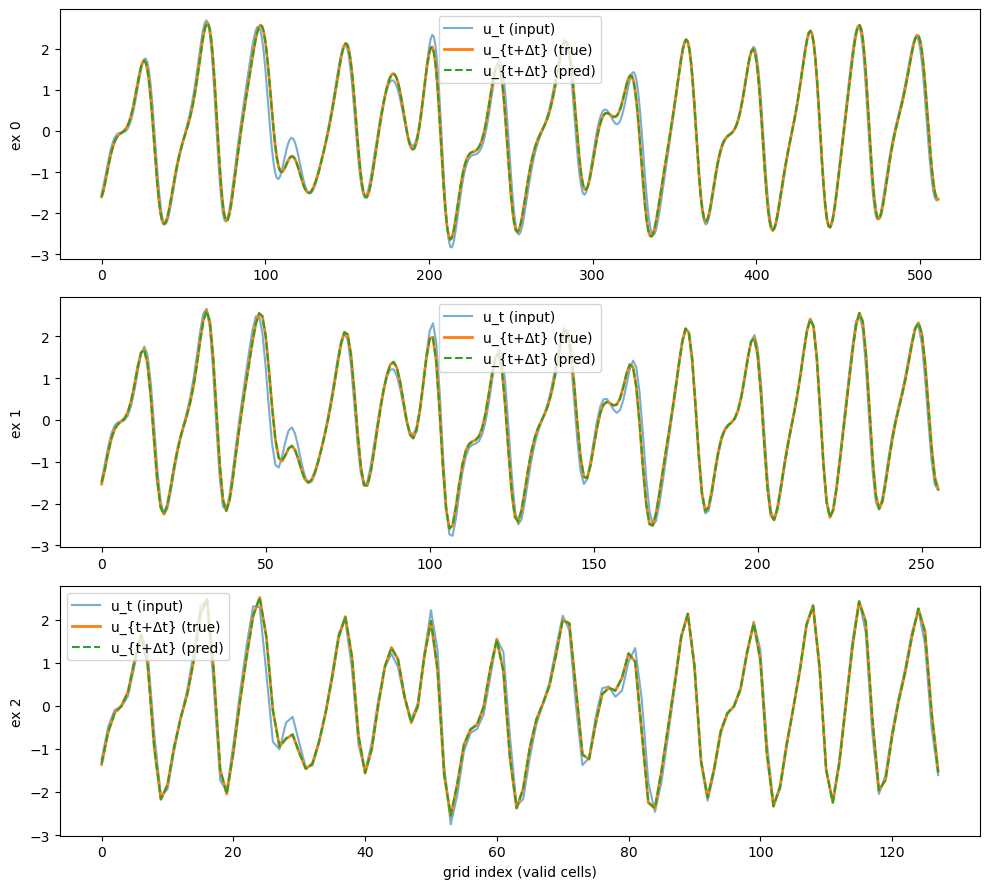

In [10]:
@torch.no_grad()
def plot_actual_vs_predicted(dl, num_examples=3):
    batch = next(iter(dl))
    profiles = batch["profiles"].to(DEVICE)
    target   = batch["target"].to(DEVICE)
    scalars  = batch["scalars"].to(DEVICE)
    mask     = batch["mask"].cpu().numpy()

    pred = model(profiles, scalars)

    u_t_n = profiles[:, 0:1, :]
    u_t   = u_t_n * U_STD + U_MEAN
    pred_du = pred   * DU_STD + DU_MEAN
    tgt_du  = target * DU_STD + DU_MEAN

    pred_next = (u_t + pred_du).squeeze(1).cpu().numpy()
    true_next = (u_t + tgt_du).squeeze(1).cpu().numpy()
    u_t_cpu   = u_t.squeeze(1).cpu().numpy()

    B = pred_next.shape[0]
    k = min(num_examples, B)
    fig, axes = plt.subplots(k, 1, figsize=(10, 3*k), sharex=False)
    if k == 1: axes = [axes]
    for i in range(k):
        m = mask[i].astype(bool)
        axes[i].plot(u_t_cpu[i, m], label="u_t (input)", alpha=0.6)
        axes[i].plot(true_next[i, m], label="u_{t+Δt} (true)", linewidth=2)
        axes[i].plot(pred_next[i, m], label="u_{t+Δt} (pred)", linestyle="--")
        axes[i].set_ylabel(f"ex {i}")
        axes[i].legend(loc="best")
    axes[-1].set_xlabel("grid index (valid cells)")
    plt.tight_layout(); plt.show()

print("\n[plot] one-step predictions on val batch")
plot_actual_vs_predicted(val_loader, num_examples=3)


[rollout] using ks_data.npy for long rollout
[rollout] ks_data as (n_traj=1, T=81, N=512)
[rollout] starting from traj 0, index T0=5, t≈3.125
[rollout] steps: 75
preds shape: (76, 512) | truth shape: (76, 512)


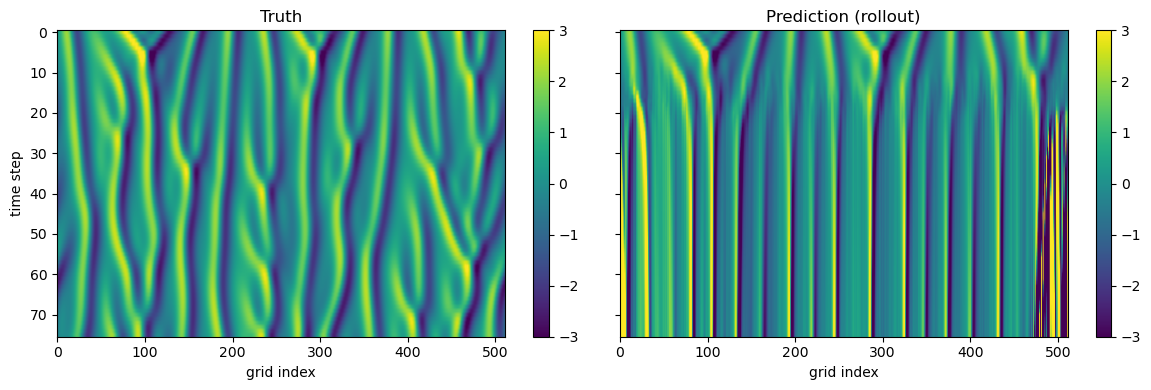

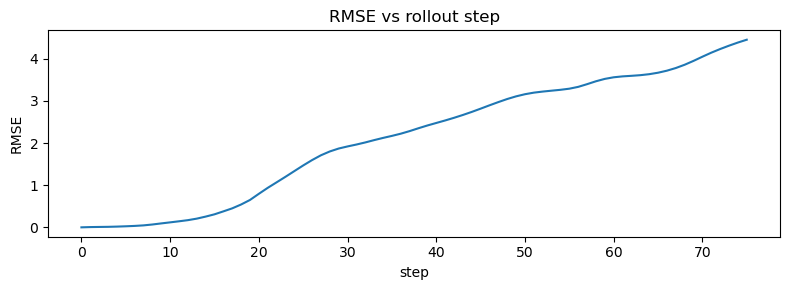

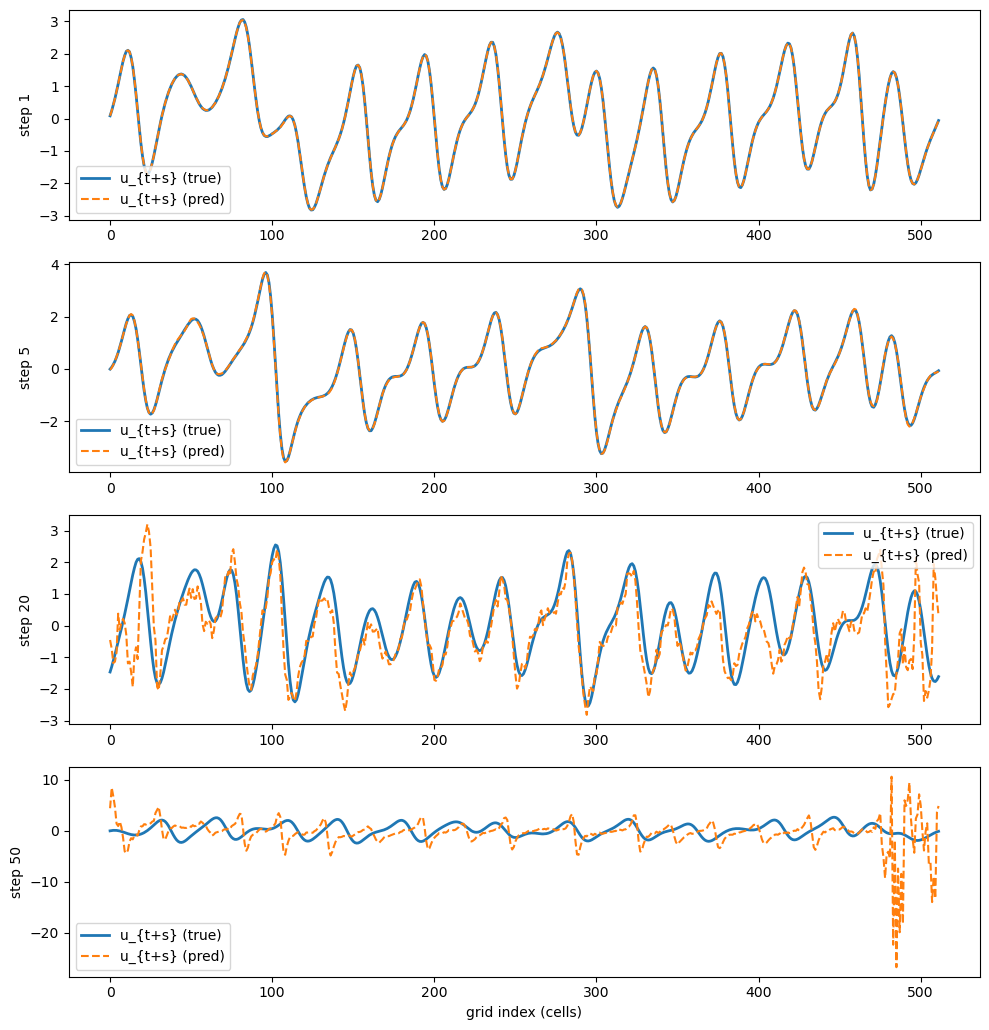

In [11]:
if U_for_rollout is not None or (DATA_DIR / "ks_data.npy").exists():
    print("\n[rollout] using ks_data.npy for long rollout")
    if U_for_rollout is None:  # when mode was supervised_pairs
        ks_data = np.load(DATA_DIR / "ks_data.npy")
        # infer shape with ks_time/ks_spatial_grid
        x_arr = loaded.get("x", np.load(DATA_DIR / "ks_spatial_grid.npy"))
        t_arr = loaded.get("t", np.load(DATA_DIR / "ks_time.npy"))
        T_guess, N_guess = len(t_arr), len(x_arr)
        # Handle both 2D (single trajectory) and 3D (multiple trajectories)
        if ks_data.ndim == 2:
            # Shapes like [T, N] or [N, T]
            if ks_data.shape == (T_guess, N_guess):
                # single realization: [T, N] -> [1, T, N]
                U_for_rollout = ks_data[None, :, :]
            elif ks_data.shape == (N_guess, T_guess):
                # stored as [N, T] -> transpose then add traj dim
                U_for_rollout = ks_data.T[None, :, :]
            else:
                raise ValueError(
                    f"Cannot interpret 2D ks_data.npy with shape {ks_data.shape} "
                    f"given T={T_guess}, N={N_guess}"
                )
        elif ks_data.ndim == 3:
            # Shapes like [T, N, R], [R, T, N], [T, R, N]
            if ks_data.shape[0] == T_guess and ks_data.shape[1] == N_guess:
                # [T, N, R] -> [R, T, N]
                U_for_rollout = np.transpose(ks_data, (2, 0, 1))
            elif ks_data.shape[1] == T_guess and ks_data.shape[2] == N_guess:
                # [R, T, N] already
                U_for_rollout = ks_data
            elif ks_data.shape[0] == T_guess and ks_data.shape[2] == N_guess:
                # [T, R, N] -> [R, T, N]
                U_for_rollout = np.transpose(ks_data, (1, 0, 2))
            else:
                raise ValueError(
                    f"Cannot interpret 3D ks_data.npy with shape {ks_data.shape} "
                    f"given T={T_guess}, N={N_guess}"
                )
        else:
            raise ValueError(
                f"ks_data.npy has unsupported ndim={ks_data.ndim}, shape={ks_data.shape}"
            )

    else:
        x_arr = loaded.get("x", np.load(DATA_DIR / "ks_spatial_grid.npy"))
        t_arr = loaded.get("t", np.load(DATA_DIR / "ks_time.npy"))

    U_traj = U_for_rollout     # [n_traj, T, N]
    n_traj, T_total, N_grid = U_traj.shape
    print(f"[rollout] ks_data as (n_traj={n_traj}, T={T_total}, N={N_grid})")

    TRAJ_ID = 0  # choose realization
    t_target = 3.0
    T0 = int(np.argmin(np.abs(t_arr - t_target)))
    print(f"[rollout] starting from traj {TRAJ_ID}, index T0={T0}, t≈{t_arr[T0]:.3f}")

    STEPS = min(1000, T_total - 1 - T0)
    print(f"[rollout] steps: {STEPS}")

    FREQS = tuple(ckpt["freqs"])
    USE_RESIDUAL_TARGET = bool(ckpt["use_residual"])

    @torch.no_grad()
    def rollout_from_state(u0, x, steps):
        pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)   # [1,Cpe,N]
        u_phys = torch.from_numpy(u0[None, None, :]).to(DEVICE)           # [1,1,N]
        preds = [u0.copy()]

        scalars_list = [float(ckpt["Lx"])]
        if ckpt["S"] >= 2 and ckpt["dt"] is not None:
            scalars_list.append(float(ckpt["dt"]))
        scalars_t = torch.tensor(scalars_list, dtype=torch.float32, device=DEVICE)[None, :]

        for _ in range(steps):
            u_norm = (u_phys - U_MEAN) / U_STD
            profiles = torch.cat([u_norm, pe], dim=1)
            d_u_norm = model(profiles, scalars_t)
            if USE_RESIDUAL_TARGET:
                d_u_phys = d_u_norm * DU_STD + DU_MEAN
                u_next = u_phys + d_u_phys
            else:
                u_next = d_u_norm * U_STD + U_MEAN
            u_phys = u_next
            preds.append(u_phys.squeeze(0).squeeze(0).cpu().numpy())
        return np.stack(preds, axis=0)

    u0 = U_traj[TRAJ_ID, T0].astype(np.float32)
    preds = rollout_from_state(u0, x_arr.astype(np.float32), STEPS)
    truth = U_traj[TRAJ_ID, T0:T0 + preds.shape[0]]

    print("preds shape:", preds.shape, "| truth shape:", truth.shape)

    rmse = np.sqrt(((preds - truth) ** 2).mean(axis=1))

    # space–time plots
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    vmin, vmax = -3.0, 3.0
    im0 = ax[0].imshow(truth, aspect="auto", vmin=vmin, vmax=vmax)
    ax[0].set_title("Truth")
    im1 = ax[1].imshow(preds, aspect="auto", vmin=vmin, vmax=vmax)
    ax[1].set_title("Prediction (rollout)")
    fig.colorbar(im0, ax=ax[0]); fig.colorbar(im1, ax=ax[1])
    for a in ax: a.set_xlabel("grid index")
    ax[0].set_ylabel("time step")
    plt.tight_layout(); plt.show()

    # RMSE vs step
    plt.figure(figsize=(8, 3))
    plt.plot(rmse)
    plt.title("RMSE vs rollout step")
    plt.xlabel("step"); plt.ylabel("RMSE")
    plt.tight_layout(); plt.show()

    # snapshot overlays from t≈3
    SNAP_STEPS = [1, 5, 20, 50, 100]
    steps_to_show = [s for s in SNAP_STEPS if 0 <= s <= STEPS]
    k = len(steps_to_show)
    fig, axes = plt.subplots(k, 1, figsize=(10, 2.6*k), sharex=False)
    if k == 1: axes = [axes]
    for ax, s in zip(axes, steps_to_show):
        ax.plot(truth[s], label="u_{t+s} (true)", linewidth=2)
        ax.plot(preds[s], label="u_{t+s} (pred)", linestyle="--")
        if s == 0:
            ax.plot(preds[0], label="u_t (input)", alpha=0.6)
        ax.set_ylabel(f"step {s}")
        ax.legend(loc="best")
    axes[-1].set_xlabel("grid index (cells)")
    # keep y-axis comparable to the PDE range
    plt.tight_layout(); plt.show()
else:
    print("\n[rollout] ks_data.npy not found; long rollout skipped")

In [12]:
print("truth min/max:", truth.min(), truth.max())
print("pred  min/max:", preds.min(), preds.max())


truth min/max: -3.6705459443837203 3.7228497097886306
pred  min/max: -45.9016 15.853312
